In [10]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.utils import sr_utils as utils
from ageing_packages.hetero_analysis import correlation_analysis as ca
from ageing_packages.hetero_analysis import twin_analysis as ta
from ageing_packages.hetero_analysis import hetero_plotting as hp
from ageing_packages.hetero_analysis import survival_analysis as sa
from ageing_packages.mortality_models.gamma_gompertz import GammaGompertz as gg
from ageing_packages.mortality_data_analysis import HMD
import numpy as np
import matplotlib.pyplot as plt

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

import pingouin as pg
import pandas as pd
from scipy import interpolate
from scipy.stats import gaussian_kde, gennorm, norm, gamma, beta
import seaborn as sns
import matplotlib.cm as cm
import sys, os, importlib, warnings, pickle
from scipy.optimize import minimize_scalar

def draw_non_negative(dist_func, size):
  dist = dist_func(size)
  mask = dist < 0
  while np.any(mask):
      dist[mask] = dist_func(np.sum(mask))
      mask = dist < 0
  return dist


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
sweden_cohort_f = HMD(country='swe', gender = 'female', data_type = 'cohort')
sweden_cohort_m = HMD(country='swe' , gender = 'male', data_type = 'cohort')
sweden_cohort_b = HMD(country='swe' , gender = 'both', data_type = 'cohort')

sweden_period_m = HMD(country='swe' , gender = 'male', data_type = 'period')
sweden_period_f = HMD(country='swe' , gender = 'female', data_type = 'period')


years = np.arange(1900, 1930, 1)

Gamma-Gompertz Makahem hazard:

$$ h(t) = m + a*e^{b t} * \frac{e^c}{e^c+e^{b t} - 1} $$

Which gives the following death-time distribution:

$$ P(t) = e^{-c - mt} \left(\frac{e^c}{-1 + e^c + e^{bt}}\right)^{1 + \frac{ae^c}{b}} \left((-1 + e^c)m + e^{bt}(ae^c + m)\right) $$

log-normal also doesn't work

# Intro

In [12]:
model = gg()

HMD_params = {
    'country': 'dan',
    'year': 1880,
    'gender': 'male', 
    'data_type': 'cohort',
    'haz_type': 'mx'
}
model.fit_params(**HMD_params, filter_from=20, filter_to=105, print_out=False)



<Axes: xlabel='Age', ylabel='Hazard [1/year]'>

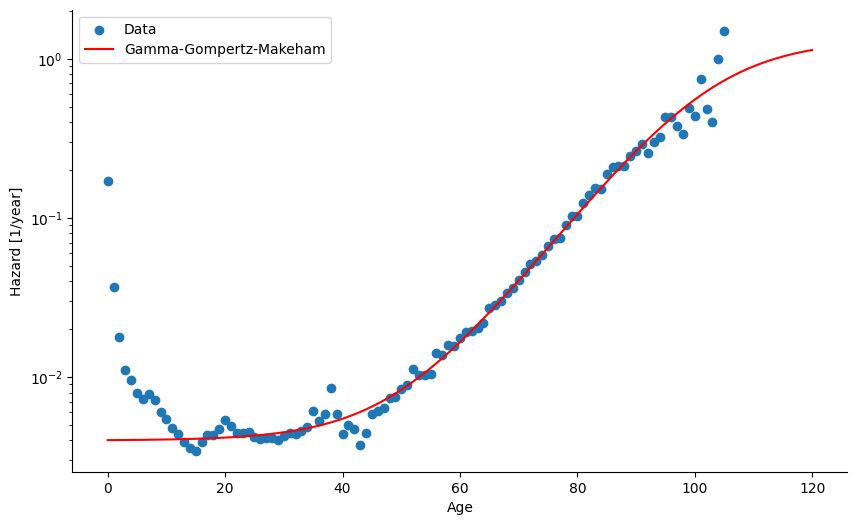

In [13]:
model.plot_hazard_with_data_comparison(**HMD_params)

90.95718379421034
92.3642097205693
95.4502829385966
99.12640371023136
98.83003201376457
99.4228167776321
99.41823900997547
100.70004089516347
101.38306089220376
102.57438908276988
102.96892012778606
101.9019673158263
102.43361002150381
103.80285964396562
102.58315951572418
103.40389626192471
103.42256320186374
104.23675087404912
103.70304867712704
103.2862342190776


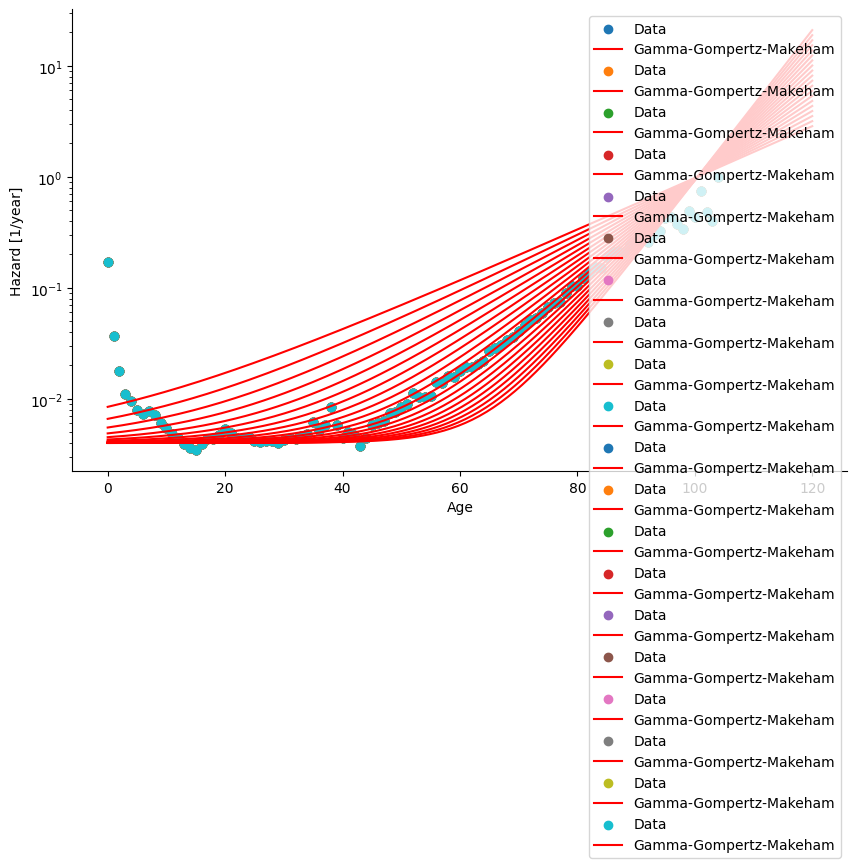

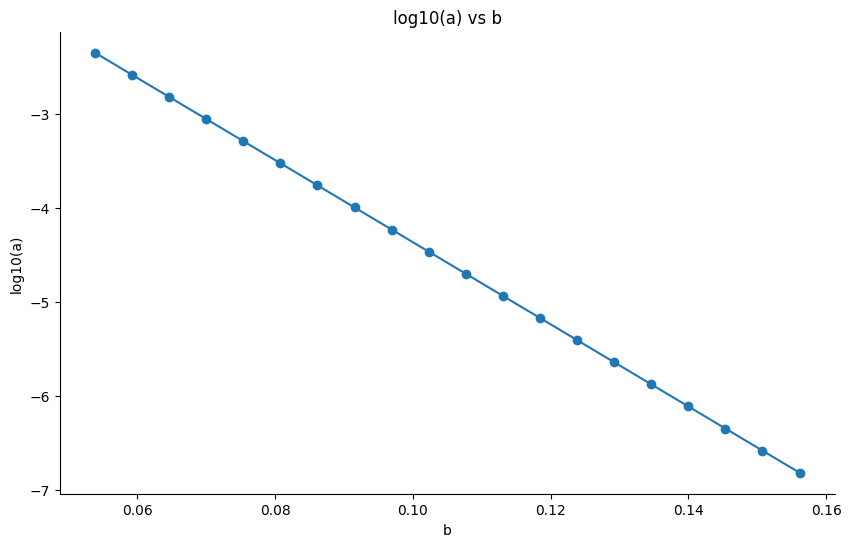

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

as_array = []
bs_array = []

for fac in np.arange(0.5, 1.5, 0.05):
    model.refit_params(print_out=False)
    model.b = model.b*fac
    model.a = model.a**fac
    model.c = 100
    as_array.append(model.a)
    bs_array.append(model.b)
    death_times = model.sample_death_times(n=100000)
    print(np.max(death_times))
    model.plot_hazard_with_data_comparison(**HMD_params, ax=ax)

# Plot log10(a) vs b
fig2, ax2 = plt.subplots(1, 1, figsize=(10, 6))
ax2.plot(bs_array, np.log10(as_array), 'o-')
ax2.set_xlabel('b')
ax2.set_ylabel('log10(a)')
ax2.set_title('log10(a) vs b')
plt.show()


# Strehler Mildvan

In [ ]:
sweden_cohort_f = HMD(country='swe', gender = 'female', data_type = 'cohort')
sweden_cohort_m = HMD(country='swe' , gender = 'male', data_type = 'cohort')
sweden_cohort_b = HMD(country='swe' , gender = 'both', data_type = 'cohort')

sweden_period_m = HMD(country='swe' , gender = 'male', data_type = 'period')
sweden_period_f = HMD(country='swe' , gender = 'female', data_type = 'period')
sweden_period_b = HMD(country='swe' , gender = 'both', data_type = 'period')
japan_period_m = HMD(country='jpn' , gender = 'both', data_type = 'period')




In [ ]:
japan_period_m.fit_gompertz(2020)

(1.9000814854160653e-05, 0.0917931670866411)

In [ ]:
np.exp(0.7)

2.0137527074704766

<Axes: title={'center': 'SM Plot for Swe, Both'}, xlabel='Gompertz $\\alpha$ [1/year]', ylabel='$ln(h_0)$'>

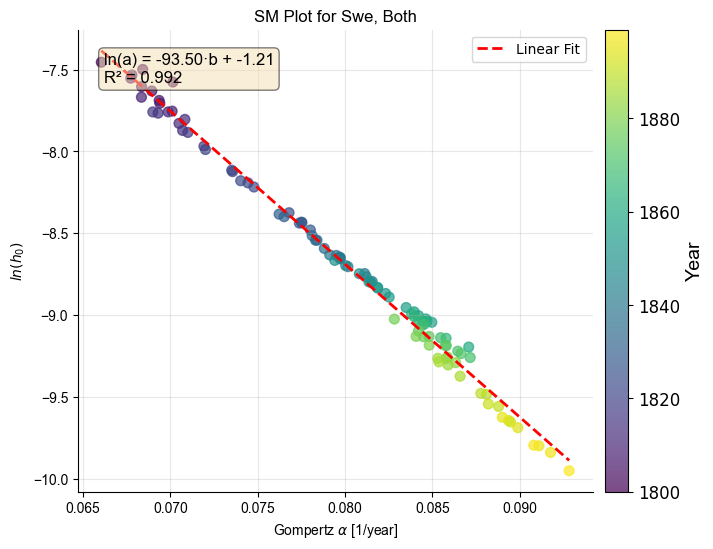

In [ ]:
years = np.arange(1800, 1900, 1)

sweden_cohort_b.plot_sm(years)

<Axes: title={'center': 'SM Plot for Swe, Both'}, xlabel='Gompertz $\\alpha$ [1/year]', ylabel='$ln(h_0)$'>

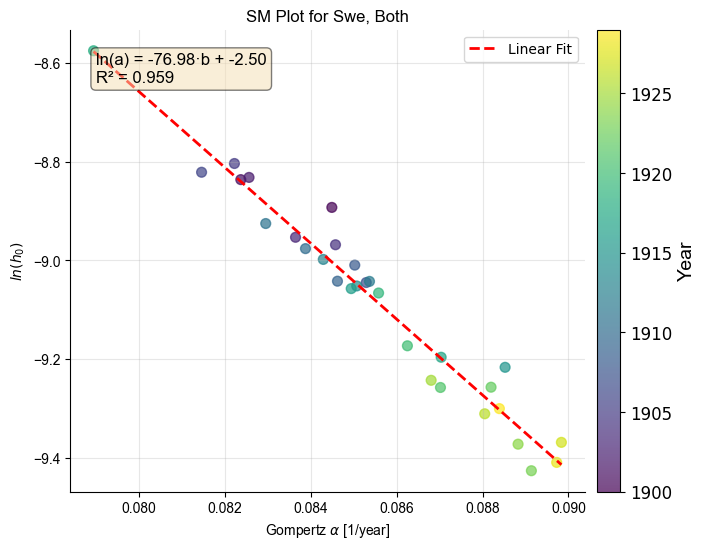

In [ ]:
years = np.arange(1900, 1930, 1)

sweden_period_b.plot_sm(years)

<Axes: title={'center': 'Hazard Rate for Swe, Female'}, xlabel='Age [years]', ylabel='Hazard Rate (mx) [1/year]'>

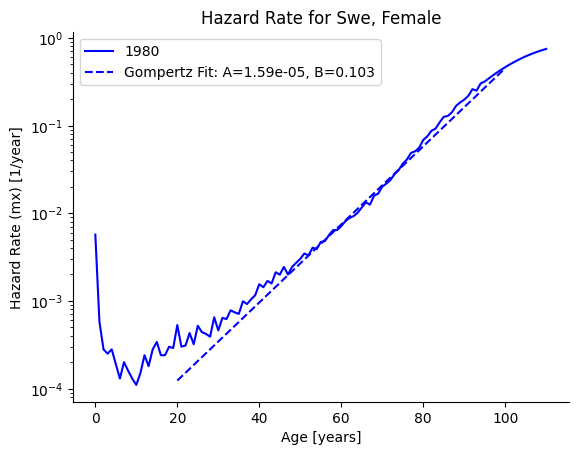

In [ ]:
sweden_period_f.plot_gompertz_fit(year = 1980)

In [ ]:
params = utils.karin_params
eta = params['eta'][0]
beta = params['beta'][0]
kappa = params['kappa'][0]
epsilon = params['epsilon'][0]
Xc = params['Xc'][0]

def compute_ln_h0(beta, epsilon, eta, Xc):
    return np.log(beta**2 / epsilon) - beta * eta * eta * Xc / epsilon

result = compute_ln_h0(beta, epsilon, eta, Xc)
print(result)



-0.30260125660417003


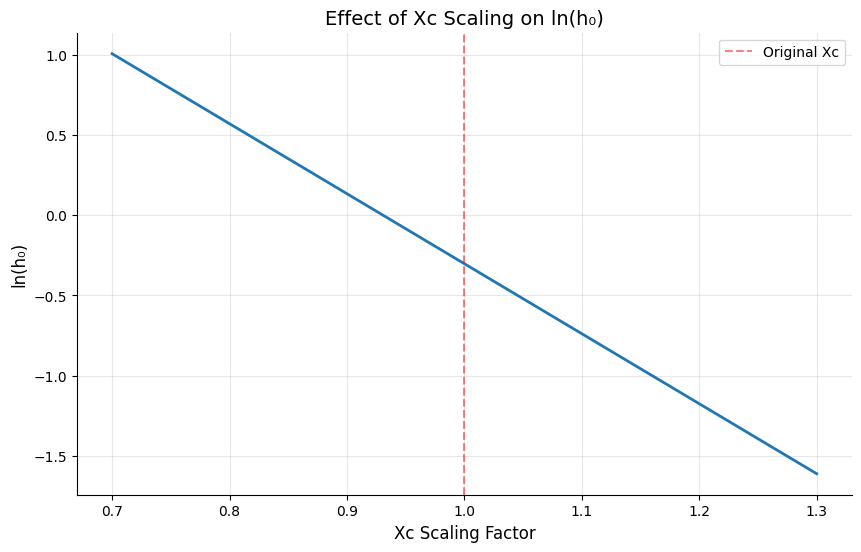

In [ ]:
factors = np.linspace(0.7, 1.3, 50)
ln_h0_values = []

for fac in factors:
    Xc_scaled = Xc * fac
    ln_h0 = compute_ln_h0(beta, epsilon, eta, Xc_scaled)
    ln_h0_values.append(ln_h0)

plt.figure(figsize=(10, 6))
plt.plot(factors, ln_h0_values, linewidth=2)
plt.xlabel('Xc Scaling Factor', fontsize=12)
plt.ylabel('ln(h₀)', fontsize=12)
plt.title('Effect of Xc Scaling on ln(h₀)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x=1.0, color='r', linestyle='--', alpha=0.5, label='Original Xc')
plt.legend()
plt.show()


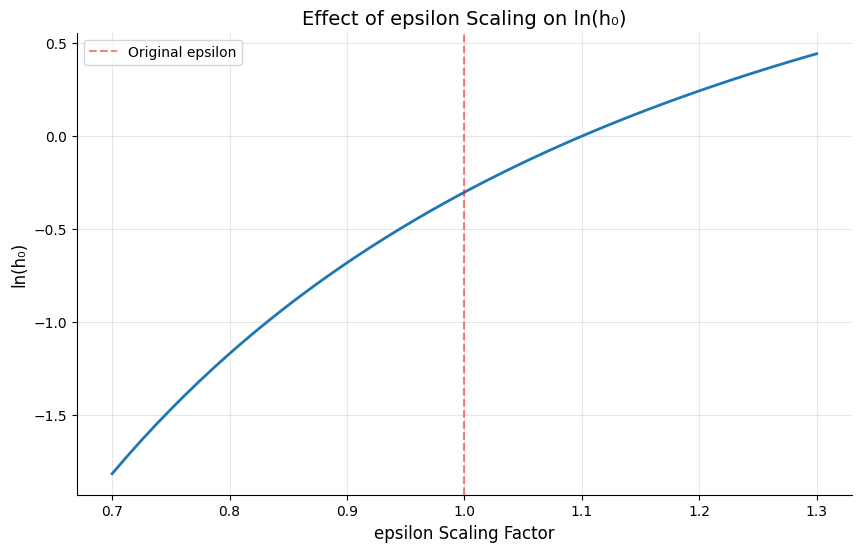

In [ ]:
factors = np.linspace(0.7, 1.3, 50)
ln_h0_values = []

for fac in factors:
    epsilon_scaled = epsilon * fac
    ln_h0 = compute_ln_h0(beta, epsilon_scaled, eta, Xc)
    ln_h0_values.append(ln_h0)

plt.figure(figsize=(10, 6))
plt.plot(factors, ln_h0_values, linewidth=2)
plt.xlabel('epsilon Scaling Factor', fontsize=12)
plt.ylabel('ln(h₀)', fontsize=12)
plt.title('Effect of epsilon Scaling on ln(h₀)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(x=1.0, color='r', linestyle='--', alpha=0.5, label='Original epsilon')
plt.legend()
plt.show()


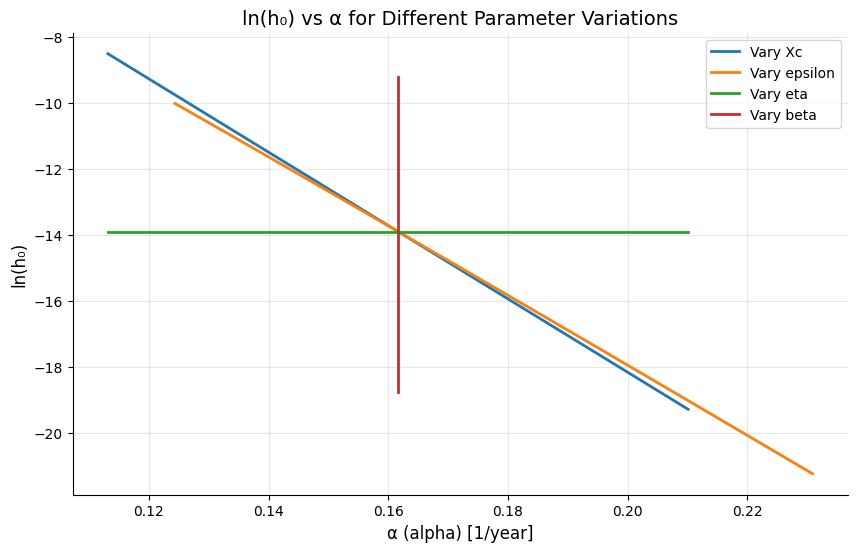

In [ ]:
# Function to compute h0 and alpha
def compute_h0_alpha(beta, epsilon, eta, Xc):
    h0 = (beta**2 / epsilon) * np.exp(-beta * Xc / epsilon)
    alpha = eta * Xc / epsilon
    return h0, alpha

# Create figure for plotting
plt.figure(figsize=(10, 6))

# Vary Xc
factors = np.linspace(0.7, 1.3, 50)
ln_h0_values_Xc = []
alpha_values_Xc = []

for fac in factors:
    Xc_scaled = Xc * fac
    h0, alpha = compute_h0_alpha(beta, epsilon, eta, Xc_scaled)
    ln_h0_values_Xc.append(np.log(h0))
    alpha_values_Xc.append(alpha)

plt.plot(alpha_values_Xc, ln_h0_values_Xc, linewidth=2, label='Vary Xc')

# Vary epsilon
ln_h0_values_epsilon = []
alpha_values_epsilon = []

for fac in factors:
    epsilon_scaled = epsilon * fac
    h0, alpha = compute_h0_alpha(beta, epsilon_scaled, eta, Xc)
    ln_h0_values_epsilon.append(np.log(h0))
    alpha_values_epsilon.append(alpha)

plt.plot(alpha_values_epsilon, ln_h0_values_epsilon, linewidth=2, label='Vary epsilon')

# Vary eta
ln_h0_values_eta = []
alpha_values_eta = []

for fac in factors:
    eta_scaled = eta * fac
    h0, alpha = compute_h0_alpha(beta, epsilon, eta_scaled, Xc)
    ln_h0_values_eta.append(np.log(h0))
    alpha_values_eta.append(alpha)

plt.plot(alpha_values_eta, ln_h0_values_eta, linewidth=2, label='Vary eta')

# Vary beta
ln_h0_values_beta = []
alpha_values_beta = []

for fac in factors:
    beta_scaled = beta * fac
    h0, alpha = compute_h0_alpha(beta_scaled, epsilon, eta, Xc)
    ln_h0_values_beta.append(np.log(h0))
    alpha_values_beta.append(alpha)

plt.plot(alpha_values_beta, ln_h0_values_beta, linewidth=2, label='Vary beta')

plt.xlabel('α (alpha) [1/year]', fontsize=12)
plt.ylabel('ln(h₀)', fontsize=12)
plt.title('ln(h₀) vs α for Different Parameter Variations', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

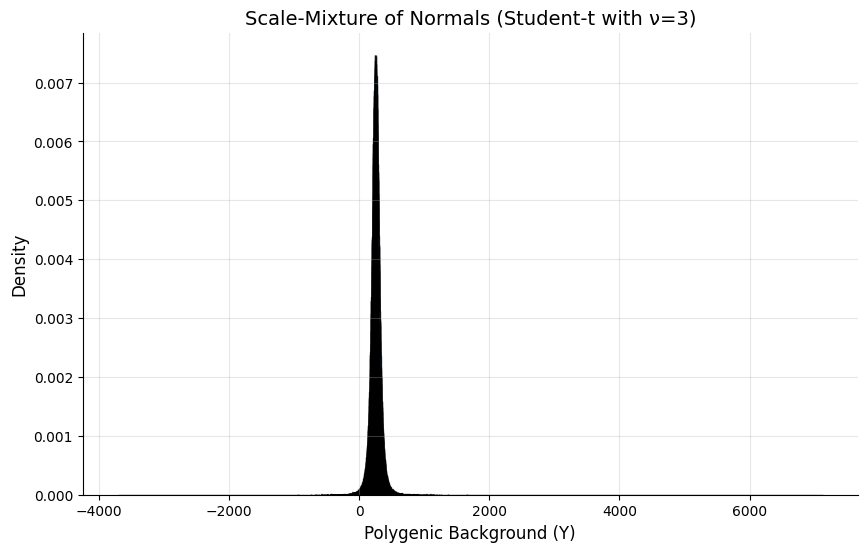

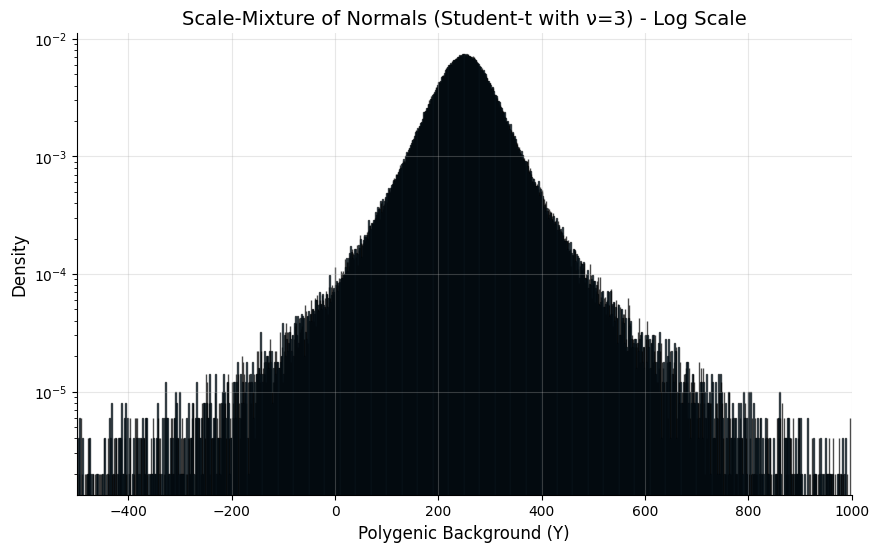

Mean: 249.90
Std dev: 85.81
Min: -3706.00, Max: 7122.00
Theoretical tail: P(|Y| > x) ~ C * x^(-4)


In [ ]:
# Scale-mixture of normals: heteroskedastic individuals
# Each person has a random variance V ~ InvGamma(nu/2, nu/2)
# Y | V ~ N(mu, sigma^2 * V)
# Marginally, Y ~ Student-t_nu

# Parameters
n_people_t = 500000
mu = 250  # mean
sigma = 50  # base scale
nu = 3  # degrees of freedom (controls tail heaviness)

# Simulate variance multipliers V ~ InvGamma(nu/2, nu/2)
from scipy.stats import invgamma
V = invgamma.rvs(a=nu/2, scale=nu/2, size=n_people_t)

# Simulate Y | V ~ N(mu, sigma^2 * V)
Y = np.random.normal(loc=mu, scale=sigma * np.sqrt(V))

# Round Y to integers
Y = np.round(Y).astype(int)

# Plot histogram
plt.figure(figsize=(10, 6))
bins = np.arange(Y.min(), Y.max() + 2) - 0.5
plt.hist(Y, bins=bins, edgecolor='black', alpha=0.7, density=True)
plt.xlabel('Polygenic Background (Y)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title(f'Scale-Mixture of Normals (Student-t with ν={nu})', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# Plot log-scale histogram to see tails
plt.figure(figsize=(10, 6))
plt.hist(Y, bins=bins, edgecolor='black', alpha=0.7, density=True)
plt.xlabel('Polygenic Background (Y)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title(f'Scale-Mixture of Normals (Student-t with ν={nu}) - Log Scale', fontsize=14)
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.xlim(-500, 1000)
plt.show()


print(f"Mean: {np.mean(Y):.2f}")
print(f"Std dev: {np.std(Y):.2f}")
print(f"Min: {np.min(Y):.2f}, Max: {np.max(Y):.2f}")
print(f"Theoretical tail: P(|Y| > x) ~ C * x^(-{nu+1})")
